In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# MLP - Multilayer perceptron  
class MLP_Network:
    def __init__(self, N_input=1, J_hidden=2, M_output=1, eta=0.3, epsilon=1e-3):
        self.N_input = N_input
        self.J_hidden = J_hidden
        self.M_output = M_output
        self.eta = eta  # Норма обучения
        self.epsilon = epsilon  # Порог ошибки
        
        # Инициализация весов (матрицы весов (rows, cols))
        self.W_ij_hidden = np.random.uniform(0, 0.9, (J_hidden, N_input))  # Вход -> скрытый слой
        # self.W_ij_hidden =  np.full((J_hidden, N_input), 0.5) 
        # self.W_ij_hidden = np.zeros((J_hidden, N_input))
        # N = 1, J = 2: W_ij_hidden = [[w1]
        #                              [w2]]

        # self.W_0j_hidden = np.zeros(J_hidden)  # Смещение скрытого слоя
        # self.W_0j_hidden =  np.full(J_hidden, 0.5) .
        self.W_0j_hidden = np.random.uniform(0, 0.9, J_hidden)
        
        # J = 2:        W_0j_hidden = [0. 0.]

        self.W_jm_output = np.random.uniform(0, 0.9, (M_output, J_hidden))  # Скрытый -> выход
        # self.W_jm_output =  np.full((M_output, J_hidden), 0.5) 
        # self.W_jm_output = np.zeros((M_output, J_hidden))
        # J = 2, M = 1: W_jm_output = [w11 w22]

        # self.W_0m_output = np.zeros(M_output)  # Смещение выходного слоя
        # self.W_0m_output =  np.full(M_output, 0.5) 
        self.W_0m_output = np.random.uniform(0, 0.9, M_output)
        # M = 1:        W_0m_output = [0.]
    
    def activation(self, net):
        # ФА скрытого и выходного слоев (Гиперболический тангенс)
        return (1 - np.exp(-net)) / (1 + np.exp(-net))
    
    def activation_derivative(self, net):
        # Производная ФА
        return 0.5 * (1 - self.activation(net) ** 2)
    
    def forward(self, x):
        # Прямое распространение ---------- ЭТАП 1
        self.net_hidden = np.dot(self.W_ij_hidden, x) + self.W_0j_hidden
        self.out_hidden = self.activation(self.net_hidden)
        self.net_output = np.dot(self.W_jm_output, self.out_hidden) + self.W_0m_output
        self.out_output = self.activation(self.net_output)
        return self.out_output
    
    def backward(self, x, target):
        # Обратное распространение ошибки - ЭТАП 2
        output_error = target - self.out_output  # Ошибка на выходе
        output_delta = output_error * self.activation_derivative(self.net_output)
        
        hidden_error = np.dot(self.W_jm_output.T, output_delta)
        hidden_delta = hidden_error * self.activation_derivative(self.net_hidden)
        
        # Обновление весов ---------------- ЭТАП 3
        self.W_jm_output += self.eta * np.outer(output_delta, self.out_hidden)
        self.W_0m_output += self.eta * output_delta

        self.W_ij_hidden += self.eta * np.outer(hidden_delta, x)
        self.W_0j_hidden += self.eta * hidden_delta
        
        # Примечание: np.outer(A, B) вычисляет внешнее произведение двух одномерных массивов
        # outer(A,B) = A * B.T
        # A = np.array([1, 2, 3]) 
        # B = np.array([4, 5]) -> np.outer(A, B):
        # [[ 4  5]
        #  [ 8 10]
         # [12 15]]
        return np.sqrt(np.sum(output_error ** 2))  # Среднеквадратичная ошибка
    
    def train(self, inputs, targets, max_epochs=1000):
        
        header = f"{'Epoch':<6} | {'Target t':<9} | {'Output y':<8} | {'Error E(k)':<10} | {'W_ij_hidden':<46} | {'W_jm_output':<20}"
        print(header)
        error_history = []

        for epoch in range(1, max_epochs + 1):
            total_error = 0
            initial_W_ij_hidden = np.copy(self.W_ij_hidden)
            initial_W_jm_output = np.copy(self.W_jm_output)
            initial_W_0j_hidden = np.copy(self.W_0j_hidden)
            initial_W_0m_output = np.copy(self.W_0m_output)
            for x, target in zip(inputs, targets):

                self.forward(x)
                total_error += self.backward(x, target) 
            
            error_history.append(total_error)
            
            weights_ij = np.concatenate([initial_W_0j_hidden, initial_W_ij_hidden.flatten()])
            weights_jm = np.concatenate([initial_W_0m_output, initial_W_jm_output.flatten()])
            weights_ij_rounded = [f"{w:.5f}" for w in weights_ij]
            weights_jm_rounded = [f"{w:.5f}" for w in weights_jm]
            # Вывод строки таблицы
            print(f"{epoch:6d} | {target[0]:9.1f} | {self.out_output[0]:8.5f} | {total_error:11.5f} | {weights_ij_rounded} | {weights_jm_rounded}")
            
            if total_error <= self.epsilon:
                break
        return error_history

N = 1, J = 2, M = 1
x = [1 2]
t = [-0.3]
eta = 0.3
Epoch  | Target t  | Output y | Error E(k) | W_ij_hidden                                    | W_jm_output         
Мы кидаем сюда: [1]
     1 |      -0.3 |  0.47950 |     0.77950 | ['0.87282', '0.36340', '0.33158', '0.68494'] | ['0.70496', '0.38307', '0.27735']
Мы кидаем сюда: [1]
     2 |      -0.3 |  0.42314 |     0.72314 | ['0.86057', '0.35380', '0.31934', '0.67534'] | ['0.61491', '0.33457', '0.23404']
Мы кидаем сюда: [1]
     3 |      -0.3 |  0.36512 |     0.66512 | ['0.84986', '0.34571', '0.30862', '0.66726'] | ['0.52587', '0.28739', '0.19188']
Мы кидаем сюда: [1]
     4 |      -0.3 |  0.30692 |     0.60692 | ['0.84082', '0.33923', '0.29958', '0.66078'] | ['0.43940', '0.24224', '0.15148']
Мы кидаем сюда: [1]
     5 |      -0.3 |  0.24998 |     0.54998 | ['0.83349', '0.33432', '0.29225', '0.65586'] | ['0.35694', '0.19973', '0.11337']
Мы кидаем сюда: [1]
     6 |      -0.3 |  0.19554 |     0.49554 | ['0.82777', '0.33085', '0.28654',

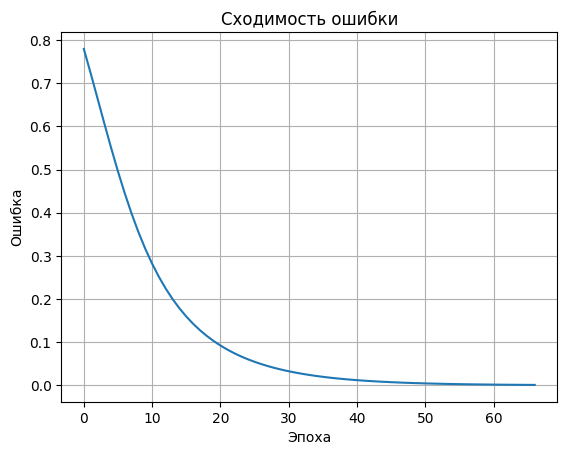

In [30]:
# Тестовые данные
inputs = np.array([[1], [2]])
# targets = np.array([[-0.3], [-0.3]])
targets = np.array([[-0.3]])
N_input=1  # число входов скрытого слоя  
J_hidden=2 # число нейронов скрытого слоя
M_output=1 # число нейронов выходного слоя

eta=0.3
epsilon=1e-3
print(f"N = {N_input}, J = {J_hidden}, M = {M_output}")
print(f"x = {inputs.flatten()}")
print(f"t = {targets.flatten()}")
print(f"eta = {eta}")
mlp = MLP_Network(N_input, J_hidden, M_output, eta, epsilon)
error_history = mlp.train(inputs, targets, max_epochs=1000)

# График ошибки
plt.plot(error_history)
plt.xlabel("Эпоха")
plt.ylabel("Ошибка")
plt.title("Сходимость ошибки")
plt.grid()
plt.show()

N = 1, J = 2, M = 1
x = [1 2]
t = [-0.3]
eta = 0.5
Epoch  | Target t  | Output y | Error E(k) | W_ij_hidden                                    | W_jm_output         
Мы кидаем сюда: [1]
     1 |      -0.3 |  0.33793 |     0.63793 | ['0.50974', '0.80911', '0.20505', '0.44405'] | ['0.15907', '0.86010', '0.44898']
Мы кидаем сюда: [1]
     2 |      -0.3 |  0.22472 |     0.52472 | ['0.45613', '0.78719', '0.15144', '0.42213'] | ['0.01780', '0.81165', '0.37048']
Мы кидаем сюда: [1]
     3 |      -0.3 |  0.12380 |     0.42380 | ['0.40997', '0.77086', '0.10528', '0.40579'] | ['-0.10676', '0.77494', '0.30317']
Мы кидаем сюда: [1]
     4 |      -0.3 |  0.03994 |     0.33994 | ['0.37212', '0.75946', '0.06743', '0.39440'] | ['-0.21108', '0.74864', '0.24802']
Мы кидаем сюда: [1]
     5 |      -0.3 | -0.02711 |     0.27289 | ['0.34184', '0.75179', '0.03715', '0.38672'] | ['-0.29593', '0.73029', '0.20386']
Мы кидаем сюда: [1]
     6 |      -0.3 | -0.07993 |     0.22007 | ['0.31782', '0.74668', '0.0131

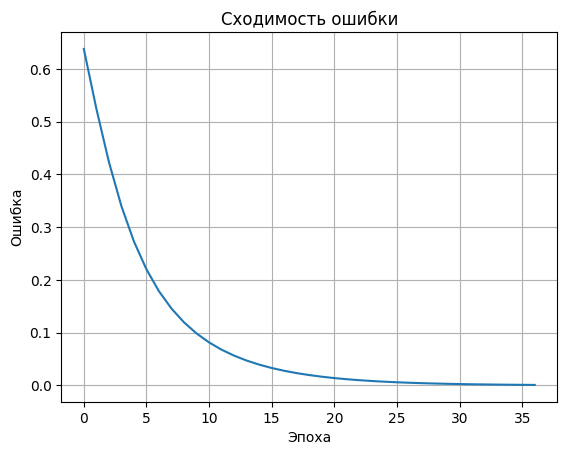

In [31]:
eta=0.5
epsilon=1e-3
print(f"N = {N_input}, J = {J_hidden}, M = {M_output}")
print(f"x = {inputs.flatten()}")
print(f"t = {targets.flatten()}")
print(f"eta = {eta}")
mlp = MLP_Network(N_input, J_hidden, M_output, eta, epsilon)
error_history = mlp.train(inputs, targets, max_epochs=1000)

# График ошибки
plt.plot(error_history)
plt.xlabel("Эпоха")
plt.ylabel("Ошибка")
plt.title("Сходимость ошибки")
plt.grid()
plt.show()

N = 1, J = 2, M = 1
x = [1 2]
t = [-0.3]
eta = 1
Epoch  | Target t  | Output y | Error E(k) | W_ij_hidden                                    | W_jm_output         
Мы кидаем сюда: [1]
     1 |      -0.3 |  0.09976 |     0.39976 | ['0.07993', '0.01136', '0.15019', '0.78532'] | ['0.09636', '0.29867', '0.18387']
Мы кидаем сюда: [1]
     2 |      -0.3 | -0.01904 |     0.28096 | ['0.05076', '-0.00423', '0.12103', '0.76973'] | ['-0.10153', '0.27600', '0.10897']
Мы кидаем сюда: [1]
     3 |      -0.3 | -0.10147 |     0.19853 | ['0.03153', '-0.01086', '0.10179', '0.76310'] | ['-0.24195', '0.26397', '0.05770']
Мы кидаем сюда: [1]
     4 |      -0.3 | -0.15785 |     0.14215 | ['0.01862', '-0.01333', '0.08888', '0.76063'] | ['-0.34019', '0.25743', '0.02240']
Мы кидаем сюда: [1]
     5 |      -0.3 | -0.19688 |     0.10312 | ['0.00972', '-0.01401', '0.07999', '0.75995'] | ['-0.40950', '0.25371', '-0.00236']
Мы кидаем сюда: [1]
     6 |      -0.3 | -0.22437 |     0.07563 | ['0.00345', '-0.01396', '0

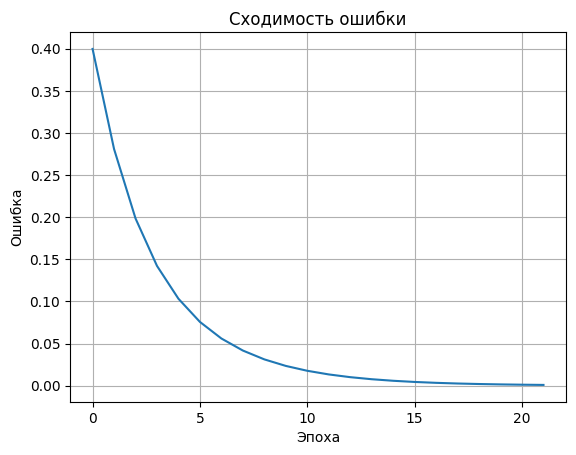

In [32]:
eta=1
epsilon=1e-3
print(f"N = {N_input}, J = {J_hidden}, M = {M_output}")
print(f"x = {inputs.flatten()}")
print(f"t = {targets.flatten()}")
print(f"eta = {eta}")
mlp = MLP_Network(N_input, J_hidden, M_output, eta, epsilon)
error_history = mlp.train(inputs, targets, max_epochs=1000)

# График ошибки
plt.plot(error_history)
plt.xlabel("Эпоха")
plt.ylabel("Ошибка")
plt.title("Сходимость ошибки")
plt.grid()
plt.show()